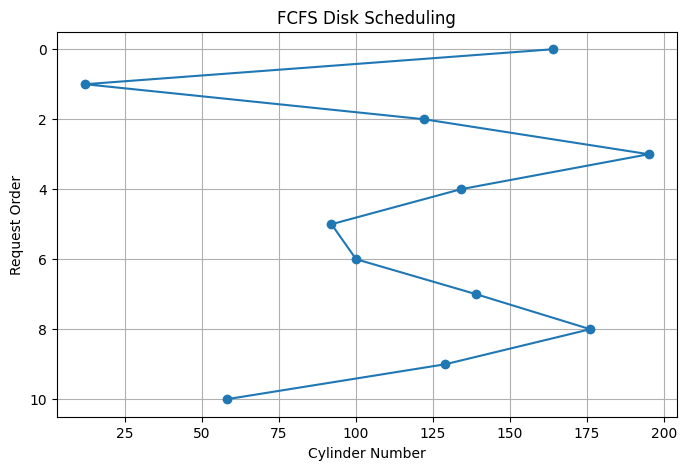

In [1]:
import random
import tkinter as tk
from tkinter import messagebox
import matplotlib.pyplot as plt

def simulate_fcfs():
    try:
        start = int(start_entry.get())
        end = int(end_entry.get())
        qsize = int(queue_entry.get())

        if start >= end:
            messagebox.showerror("Error", "Start must be less than End")
            return

        # Generate random request queue
        queue = [random.randint(start, end) for _ in range(qsize)]

        # Random head position
        head = random.randint(start, end)

        order = [head] + queue
        total_moves = 0

        for i in range(len(order) - 1):
            total_moves += abs(order[i+1] - order[i])

        result_label.config(
            text=f"Queue: {queue}\nHead Start: {head}\nTotal Head Movement: {total_moves}"
        )

        # Plot graph
        plt.figure(figsize=(8,5))
        plt.plot(order, range(len(order)), marker='o')
        plt.gca().invert_yaxis()
        plt.title("FCFS Disk Scheduling")
        plt.xlabel("Cylinder Number")
        plt.ylabel("Request Order")
        plt.grid(True)
        plt.show()

    except:
        messagebox.showerror("Error", "Invalid Input")

# GUI
root = tk.Tk()
root.title("FCFS Disk Scheduling Simulation")
root.geometry("400x300")

tk.Label(root, text="Start Cylinder").pack()
start_entry = tk.Entry(root)
start_entry.pack()

tk.Label(root, text="End Cylinder").pack()
end_entry = tk.Entry(root)
end_entry.pack()

tk.Label(root, text="Queue Size").pack()
queue_entry = tk.Entry(root)
queue_entry.pack()

tk.Button(root, text="Simulate FCFS", command=simulate_fcfs).pack(pady=10)

result_label = tk.Label(root, text="")
result_label.pack()

root.mainloop()

Request Queue: [99, 175, 144, 4, 70, 58, 134, 19, 61, 119]
Initial Head Position: 194
Total Head Movements: 711


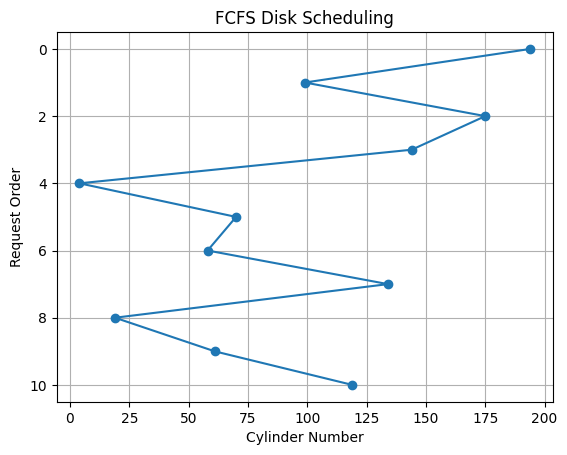

In [ ]:
import random
import matplotlib.pyplot as plt

start = int(input("Enter start cylinder: "))
end = int(input("Enter end cylinder: "))
qsize = int(input("Enter queue size: "))

queue = [random.randint(start, end) for _ in range(qsize)]

head = random.randint(start, end)

print("Request Queue:", queue)
print("Initial Head Position:", head)

order = [head] + queue

total_moves = 0
for i in range(len(order)-1):
    move = abs(order[i+1] - order[i])
    total_moves += move

print("Total Head Movements:", total_moves)

plt.plot(order, range(len(order)), marker='o')
plt.gca().invert_yaxis()
plt.title("FCFS Disk Scheduling")
plt.xlabel("Cylinder Number")
plt.ylabel("Request Order")
plt.grid(True)

plt.show()

Request Queue: [42, 138, 12, 82, 151, 36, 52, 186, 5, 195]
Initial Head Position: 29
Service Order: [29, 36, 42, 52, 82, 138, 151, 186, 195, 12, 5]
Total Head Movements: 356


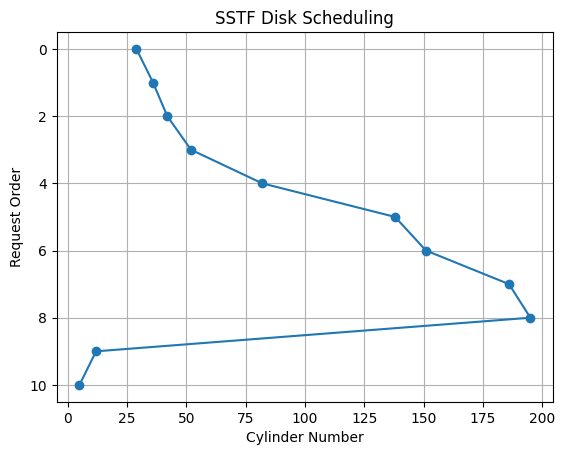

In [3]:
import random
import matplotlib.pyplot as plt

# Input
start = int(input("Enter start cylinder: "))
end = int(input("Enter end cylinder: "))
qsize = int(input("Enter queue size: "))

# Random request queue
queue = [random.randint(start, end) for _ in range(qsize)]

# Random head position
head = random.randint(start, end)

print("Request Queue:", queue)
print("Initial Head Position:", head)

requests = queue.copy()
order = [head]
total_moves = 0
current = head

# SSTF algorithm
while requests:
    nearest = min(requests, key=lambda x: abs(x - current))
    move = abs(nearest - current)
    total_moves += move
    current = nearest

    order.append(nearest)
    requests.remove(nearest)

print("Service Order:", order)
print("Total Head Movements:", total_moves)

# Graph
plt.plot(order, range(len(order)), marker='o')
plt.gca().invert_yaxis()
plt.title("SSTF Disk Scheduling")
plt.xlabel("Cylinder Number")
plt.ylabel("Request Order")
plt.grid(True)

plt.show()

Queue: [105, 28, 164, 53, 168, 47, 13, 32, 161, 199]
Head: 143
Service Order: [143, 161, 164, 168, 199, 200, 105, 53, 47, 32, 28, 13]
Total Head Movement: 244


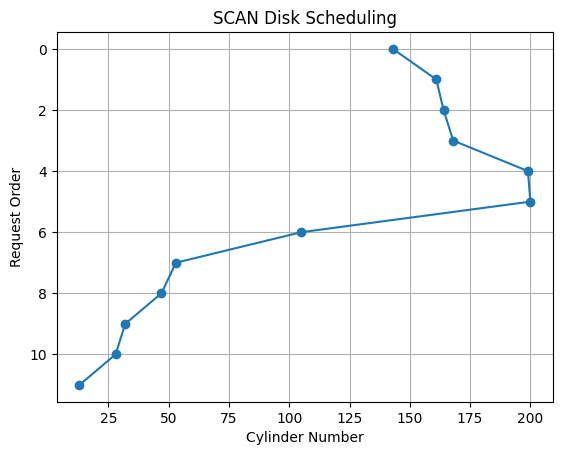

In [5]:
import random
import matplotlib.pyplot as plt

start = int(input("Enter start cylinder: "))
end = int(input("Enter end cylinder: "))
qsize = int(input("Enter queue size: "))
direction = input("Enter direction (left/right): ").lower()

# Generate random queue
queue = [random.randint(start, end) for _ in range(qsize)]

# Random head position
head = random.randint(start, end)

print("Queue:", queue)
print("Head:", head)

left = [x for x in queue if x < head]
right = [x for x in queue if x >= head]

left.sort()
right.sort()

order = [head]

if direction == "left":
    left.reverse()
    order += left
    order.append(start)
    order += right

else:
    order += right
    order.append(end)
    left.reverse()
    order += left

# Calculate total movement
total_moves = 0
for i in range(len(order)-1):
    total_moves += abs(order[i+1] - order[i])

print("Service Order:", order)
print("Total Head Movement:", total_moves)

# Graph
plt.plot(order, range(len(order)), marker='o')
plt.gca().invert_yaxis()
plt.title("SCAN Disk Scheduling")
plt.xlabel("Cylinder Number")
plt.ylabel("Request Order")
plt.grid(True)

plt.show()


Generated Queue: [8, 8, 58, 125, 50, 184, 169, 28, 59, 88]
Head Position: 110

----- Disk Scheduling Menu -----
1. FCFS
2. SSTF
3. SCAN
4. Exit
Service Order: [110, 8, 8, 58, 125, 50, 184, 169, 28, 59, 88]
Total Head Movement: 644


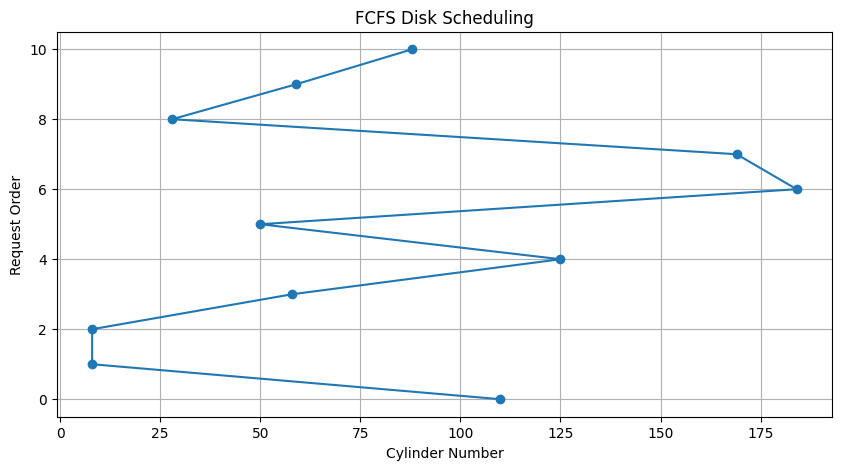

In [ ]:
import random
import matplotlib.pyplot as plt

def plot_graph(order, title):

    plt.figure(figsize=(10,5))

    x = order
    y = list(range(len(order)))

    plt.plot(x, y, marker='o')

    ax = plt.gca()

    plt.xlabel("Cylinder Number")
    plt.ylabel("Request Order")
    plt.title(title)

    plt.grid(True)

    plt.show()

def fcfs(queue, head):
    order = [head] + queue
    total = 0
    
    for i in range(len(order)-1):
        total += abs(order[i+1] - order[i])
        
    print("Service Order:", order)
    print("Total Head Movement:", total)
    
    plot_graph(order, "FCFS Disk Scheduling")

def sstf(queue, head):
    requests = queue.copy()
    current = head
    order = [head]
    total = 0

    while requests:
        nearest = min(requests, key=lambda x: abs(x-current))
        total += abs(nearest-current)
        current = nearest
        
        order.append(nearest)
        requests.remove(nearest)

    print("Service Order:", order)
    print("Total Head Movement:", total)

    plot_graph(order, "SSTF Disk Scheduling")

def scan(queue, head, start, end, direction):
    left = [x for x in queue if x < head]
    right = [x for x in queue if x >= head]

    left.sort()
    right.sort()

    order = [head]

    if direction == "left":
        left.reverse()
        order += left
        order.append(start)
        order += right

    else:
        order += right
        order.append(end)
        left.reverse()
        order += left

    total = 0
    for i in range(len(order)-1):
        total += abs(order[i+1]-order[i])

    print("Service Order:", order)
    print("Total Head Movement:", total)

    plot_graph(order, "SCAN Disk Scheduling")



# ---- Main Program ----

start = int(input("Enter start cylinder: "))
end = int(input("Enter end cylinder: "))
qsize = int(input("Enter queue size: "))

queue = [random.randint(start, end) for _ in range(qsize)]
head = random.randint(start, end)

print("\nGenerated Queue:", queue)
print("Head Position:", head)

print("\n----- Disk Scheduling Menu -----")
print("1. FCFS")
print("2. SSTF")
print("3. SCAN")

choice = int(input("Enter choice: "))

if choice == 1:
    fcfs(queue, head)

elif choice == 2:
    sstf(queue, head)

elif choice == 3:
    direction = input("Enter direction (left/right): ")
    scan(queue, head, start, end, direction)
else:
    print("Invalid choice")
